# Email Threat Classification Project

This is a beginner-friendly notebook for classifying emails into routine and potentially threatening categories. It covers Data Loading, Exploratory Data Analysis (EDA), Preprocessing, Model Building, and Evaluation.

## Installation
First, let's install the necessary libraries if you haven't already. You can uncomment the line below to install them.

In [13]:
# !pip install datasets pandas matplotlib seaborn scikit-learn

## 1. Import Libraries

In [14]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Set plot styles for better visualization
sns.set_theme(style="whitegrid")

## 2. Load Dataset
We will load the requested dataset from Hugging Face.

In [15]:
# Load the dataset
ds = load_dataset("SofienK-s/seven-phishing-email-datasets")
print(ds)

# Convert the 'train' split to a pandas DataFrame for easier analysis
df = ds['train'].to_pandas()

# Let's look at the first few rows
print(df.head())

DatasetDict({
    train: Dataset({
        features: ['text', 'subject', 'label', 'sender', 'receiver', 'date', 'urls', 'dataset_name'],
        num_rows: 162413
    })
    test: Dataset({
        features: ['text', 'subject', 'label', 'sender', 'receiver', 'date', 'urls', 'dataset_name'],
        num_rows: 40604
    })
})
                                                text  \
0  \n \n \n\n\nmeat helpful round An afterclang o...   
1  Avail to the E-store and avail to timely suppo...   
2  sorry...when did you get out of here yesterday...   
3  Does anyone know of any upcoming Lesson Study ...   
4  GADSDEN RESEARCH SERVICES' FERCwatch    Octobe...   

                                           subject  label  \
0                             When will it be okay      1   
1  Havea method to reduce the high expense of iink      1   
2                                             RE:       0   
3                                       open house      0   
4         GRS/FERCwatch - FERC AG

## 3. Exploratory Data Analysis (EDA)
Let's understand our data better: check for missing values and look at the class balance.

In [16]:
# Check dataset information
print("\nDataset Info:")
df.info()

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 162413 entries, 0 to 162412
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   text          162413 non-null  str           
 1   subject       162413 non-null  str           
 2   label         162413 non-null  int64         
 3   sender        136273 non-null  str           
 4   receiver      136273 non-null  str           
 5   date          133515 non-null  datetime64[ns]
 6   urls          136273 non-null  float64       
 7   dataset_name  162413 non-null  str           
dtypes: datetime64[ns](1), float64(1), int64(1), str(5)
memory usage: 312.5 MB

Missing Values:
text                0
subject             0
label               0
sender          26140
receiver        26140
date            28898
urls            26140
dataset_name        0
dtype: int64



Using 'text' for text and 'label' for labels.

Class Distribution:
label
0    86951
1    75462
Name: count, dtype: int64


C:\Users\sagni\AppData\Local\Temp\ipykernel_19404\1749887837.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette="Set2")


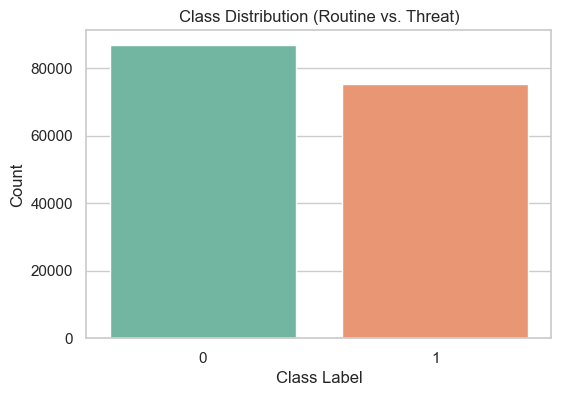

In [17]:
# Identify the target column (usually 'label' or 'class')
target_col = 'label' if 'label' in df.columns else df.columns[-1]
text_col = 'text' if 'text' in df.columns else df.columns[0]

print(f"\nUsing '{text_col}' for text and '{target_col}' for labels.")

# Check class balance
print("\nClass Distribution:")
print(df[target_col].value_counts())

# Visualize the class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col, palette="Set2")
plt.title('Class Distribution (Routine vs. Threat)')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.show()

## 4. Data Preprocessing & Feature Engineering
We need to handle missing values and extract features like message length before converting the text to numbers.

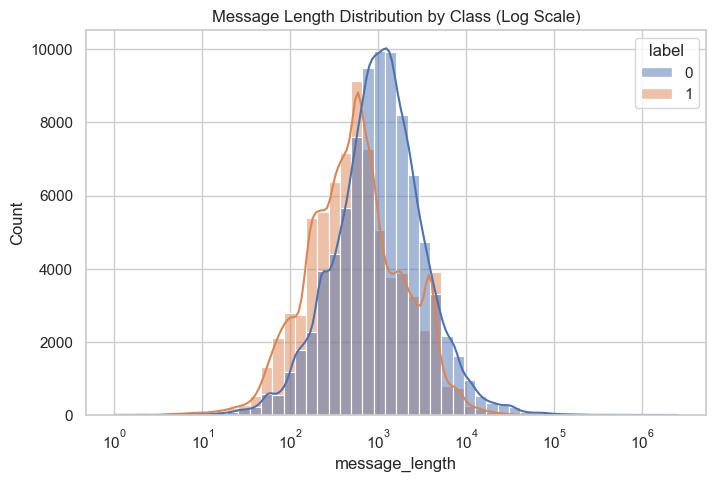

Training set size: 129930
Testing set size: 32483


In [18]:
# 1. Handle missing text (if any) by replacing with empty string
df[text_col] = df[text_col].fillna('')

# 2. Extract a basic feature: Message Length
df['message_length'] = df[text_col].apply(len)

# Visualize message length distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df[df['message_length'] > 0], x='message_length', hue=target_col, bins=50, kde=True, log_scale=True)
plt.title('Message Length Distribution by Class (Log Scale)')
plt.show()

# 3. Split the data into Training and Testing sets (80% train, 20% test)
X = df[text_col]
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

### Text Vectorization (TF-IDF)
Machine learning models need numbers, not text. We use TF-IDF to convert our email text into numerical features based on word frequencies.

In [19]:
# Initialize TF-IDF Vectorizer
# We limit to top 5000 features to keep the model fast and lightweight
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

# Fit on training data and transform both train and test data
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Vectorized training data shape: {X_train_vec.shape}")

Vectorized training data shape: (129930, 5000)


## 5. Model Building
We use **Logistic Regression** as it is a foundational, highly interpretable model that works very well for text classification baselines.

In [20]:
# Initialize and train the model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_vec, y_train)

print("Model training complete!")

Model training complete!


## 6. Evaluation
We will evaluate the model using Accuracy, Precision, Recall, F1-score, and a Confusion Matrix.

In [21]:
# Make predictions on the test set
y_pred = model.predict(X_test_vec)

# Calculate metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("--- Model Evaluation Metrics ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

# Detailed Classification Report
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

--- Model Evaluation Metrics ---
Accuracy:  0.9676
Precision: 0.9676
Recall:    0.9676
F1-score:  0.9676

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     17390
           1       0.96      0.97      0.97     15093

    accuracy                           0.97     32483
   macro avg       0.97      0.97      0.97     32483
weighted avg       0.97      0.97      0.97     32483



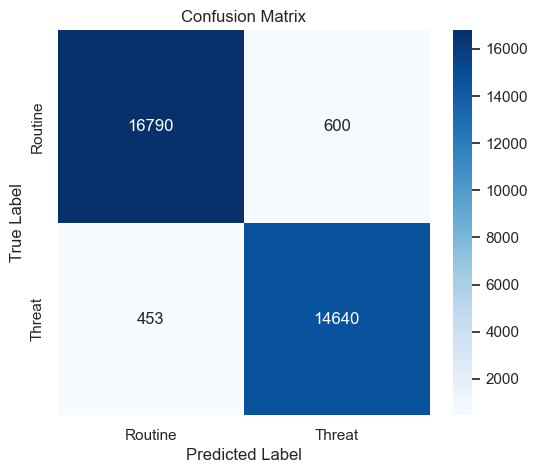

In [22]:
# Plot Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Routine', 'Threat'], 
            yticklabels=['Routine', 'Threat'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 8. Exporting the Model
We will save the trained model and vectorizer using `joblib` so that our Streamlit application can load and use them.

In [ ]:
import joblib
import os

# Save the trained model and the vectorizer to disk
print("Saving model and vectorizer...")
joblib.dump(model, 'model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

print("Done! model.pkl and vectorizer.pkl have been created.")